# Graphs and Algorithms: From Roads to Trade Costs

This notebook teaches the graph theory and algorithms behind the Chasing Pavements project. We'll start with the simplest possible example and build up to the full Tanzania road network.

**What you'll learn:**
1. What a graph is and why it's the right abstraction for road networks
2. How to represent graphs as matrices
3. How Dijkstra's algorithm finds shortest paths
4. How weighted graphs give us trade costs
5. How all of this connects to the GE model

## 1. What is a Graph?

A **graph** is the simplest possible representation of a network: just **nodes** (points) connected by **edges** (links).

Think of 5 towns in Tanzania connected by roads:

```
    Arusha -------- Dodoma
      |    \          |    
      |     \         |    
    Mwanza   \     Dar es Salaam
      |       \      /
      |        \    /
    Mbeya ------Iringa
```

- **Nodes**: Arusha, Mwanza, Mbeya, Dodoma, Dar es Salaam, Iringa (6 nodes)
- **Edges**: The roads connecting them (7 edges)

That's a graph. Let's build it in code.

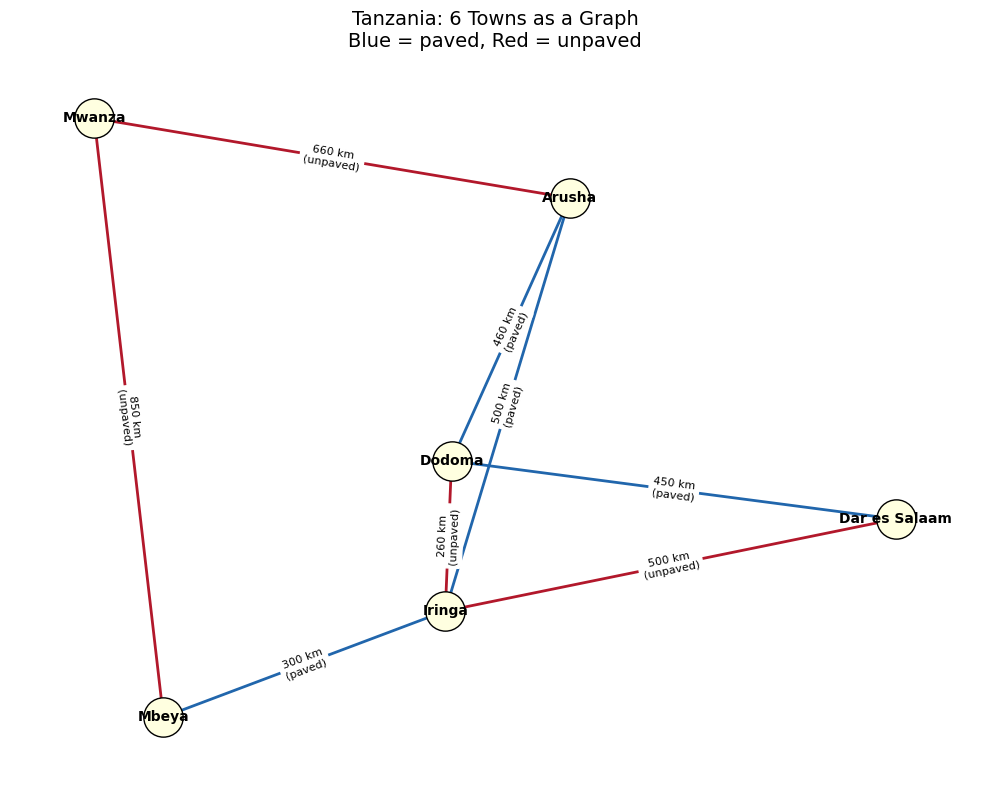

Nodes: 6
Edges: 8


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

# Define our 6 towns with approximate coordinates (lon, lat)
towns = {
    'Arusha':       (36.68, -3.37),
    'Dodoma':       (35.74, -6.17),
    'Dar es Salaam':(39.27, -6.79),
    'Mwanza':       (32.90, -2.52),
    'Mbeya':        (33.45, -8.90),
    'Iringa':       (35.69, -7.77),
}

# Define roads between them: (town_a, town_b, distance_km, surface)
roads = [
    ('Arusha', 'Dodoma', 460, 'paved'),
    ('Arusha', 'Mwanza', 660, 'unpaved'),
    ('Arusha', 'Iringa', 500, 'paved'),
    ('Dodoma', 'Dar es Salaam', 450, 'paved'),
    ('Dodoma', 'Iringa', 260, 'unpaved'),
    ('Mwanza', 'Mbeya', 850, 'unpaved'),
    ('Mbeya', 'Iringa', 300, 'paved'),
    ('Iringa', 'Dar es Salaam', 500, 'unpaved'),
]

# Build and draw the graph
G = nx.Graph()
for name, (lon, lat) in towns.items():
    G.add_node(name, pos=(lon, lat))

for a, b, dist, surface in roads:
    G.add_edge(a, b, distance=dist, surface=surface)

# Draw it
fig, ax = plt.subplots(figsize=(10, 8))
pos = nx.get_node_attributes(G, 'pos')

# Color edges by surface
edge_colors = ['#2166ac' if G[u][v]['surface'] == 'paved' else '#b2182b' 
               for u, v in G.edges()]

nx.draw(G, pos, ax=ax, with_labels=True, node_size=800, node_color='lightyellow',
        edge_color=edge_colors, width=2, font_size=10, font_weight='bold',
        edgecolors='black')

# Add edge labels (distance)
edge_labels = {(u, v): f"{d['distance']} km\n({d['surface']})" 
               for u, v, d in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)

ax.set_title('Tanzania: 6 Towns as a Graph\nBlue = paved, Red = unpaved', fontsize=14)
plt.tight_layout()
plt.show()

print(f"Nodes: {G.number_of_nodes()}")
print(f"Edges: {G.number_of_edges()}")

**Key insight:** A graph strips away all the geographic detail (curves, terrain, intermediate points) and keeps only what matters for routing: **which places are connected, and at what cost.**

The Tanzania road network we built in `network.py` is exactly this, but with 2 million nodes (intersections) and 2.6 million edges (road segments) instead of 6 and 8.

## 2. Adjacency Matrices

A graph can be stored as a **matrix**. If we have `n` nodes, the **adjacency matrix** is an `n × n` grid where entry `(i, j)` is the weight of the edge between node `i` and node `j`. If there's no edge, the entry is 0 (or infinity).

Let's build the adjacency matrix for our 6-town example:

In [2]:
import pandas as pd

# Create adjacency matrix (distances only)
town_names = list(towns.keys())
n = len(town_names)
adj = np.full((n, n), np.inf)  # infinity = no direct road
np.fill_diagonal(adj, 0)       # distance to yourself = 0

name_to_idx = {name: i for i, name in enumerate(town_names)}

for a, b, dist, surface in roads:
    i, j = name_to_idx[a], name_to_idx[b]
    adj[i, j] = dist
    adj[j, i] = dist  # undirected: road works both ways

# Display as a nice table
adj_df = pd.DataFrame(adj, index=town_names, columns=town_names)
print("Adjacency Matrix (direct road distances in km):")
print(adj_df.replace(np.inf, '---').to_string())

print(f"\nThis is a {n}×{n} matrix.")
print(f"Entries with numbers: direct roads exist.")
print(f"Entries with ---: no direct road (must go through other towns).")

Adjacency Matrix (direct road distances in km):
              Arusha Dodoma Dar es Salaam Mwanza  Mbeya Iringa
Arusha           0.0  460.0           ---  660.0    ---  500.0
Dodoma         460.0    0.0         450.0    ---    ---  260.0
Dar es Salaam    ---  450.0           0.0    ---    ---  500.0
Mwanza         660.0    ---           ---    0.0  850.0    ---
Mbeya            ---    ---           ---  850.0    0.0  300.0
Iringa         500.0  260.0         500.0    ---  300.0    0.0

This is a 6×6 matrix.
Entries with numbers: direct roads exist.
Entries with ---: no direct road (must go through other towns).


**Notice:** Mwanza → Dar es Salaam is `---` (infinity). There's no direct road. To get there, you'd need to go through other towns (e.g., Mwanza → Arusha → Dodoma → Dar es Salaam). Finding the cheapest such route is exactly what Dijkstra's algorithm does.

**Sparse matrices:** In our 6-town example, most entries have values. But in the real Tanzania network (2M × 2M matrix), 99.9999% of entries would be zero — a node is only directly connected to its immediate neighbors. We store this as a **sparse matrix** (only keeping the nonzero entries) to save memory.

## 3. Dijkstra's Algorithm: Finding Cheapest Paths

**The problem:** Given a starting town, find the cheapest route to every other town.

**The algorithm** (invented by Edsger Dijkstra in 1956):

1. Start at the source. Set its cost to 0. Set all other costs to infinity.
2. Pick the unvisited node with the lowest cost.
3. For each neighbor of that node: if going through this node is cheaper than the current best, update the cost.
4. Mark this node as visited.
5. Repeat until all nodes are visited.

That's it. Let's watch it work step by step:

In [3]:
def dijkstra_verbose(adj, source_idx, names):
    """Dijkstra's algorithm with step-by-step output."""
    n = len(adj)
    dist = np.full(n, np.inf)   # best known cost to each node
    dist[source_idx] = 0
    visited = np.zeros(n, dtype=bool)
    prev = np.full(n, -1, dtype=int)  # track the path
    
    print(f"Starting from: {names[source_idx]}")
    print(f"{'='*70}")
    
    for step in range(n):
        # Pick unvisited node with lowest cost
        unvisited_dist = np.where(visited, np.inf, dist)
        current = np.argmin(unvisited_dist)
        
        if dist[current] == np.inf:
            break  # remaining nodes are unreachable
        
        print(f"\nStep {step+1}: Visit {names[current]} (cost = {dist[current]:.0f} km)")
        visited[current] = True
        
        # Check each neighbor
        for neighbor in range(n):
            if visited[neighbor] or adj[current, neighbor] == np.inf:
                continue
            
            new_cost = dist[current] + adj[current, neighbor]
            if new_cost < dist[neighbor]:
                old = f"{dist[neighbor]:.0f}" if dist[neighbor] < np.inf else "inf"
                print(f"  → {names[neighbor]}: {old} → {new_cost:.0f} km "
                      f"(via {names[current]}, road = {adj[current, neighbor]:.0f} km) ✓ UPDATED")
                dist[neighbor] = new_cost
                prev[neighbor] = current
            else:
                print(f"  → {names[neighbor]}: {dist[neighbor]:.0f} ≤ {new_cost:.0f} km (no improvement)")
    
    # Print final results
    print(f"\n{'='*70}")
    print(f"Shortest paths from {names[source_idx]}:")
    for i in range(n):
        if i == source_idx:
            continue
        # Reconstruct path
        path = []
        node = i
        while node != -1:
            path.append(names[node])
            node = prev[node]
        path.reverse()
        print(f"  → {names[i]:15s}: {dist[i]:>6.0f} km  path: {' → '.join(path)}")
    
    return dist, prev

# Run from Mwanza
dist_from_mwanza, _ = dijkstra_verbose(adj, name_to_idx['Mwanza'], town_names)

Starting from: Mwanza

Step 1: Visit Mwanza (cost = 0 km)
  → Arusha: inf → 660 km (via Mwanza, road = 660 km) ✓ UPDATED
  → Mbeya: inf → 850 km (via Mwanza, road = 850 km) ✓ UPDATED

Step 2: Visit Arusha (cost = 660 km)
  → Dodoma: inf → 1120 km (via Arusha, road = 460 km) ✓ UPDATED
  → Iringa: inf → 1160 km (via Arusha, road = 500 km) ✓ UPDATED

Step 3: Visit Mbeya (cost = 850 km)
  → Iringa: 1160 → 1150 km (via Mbeya, road = 300 km) ✓ UPDATED

Step 4: Visit Dodoma (cost = 1120 km)
  → Dar es Salaam: inf → 1570 km (via Dodoma, road = 450 km) ✓ UPDATED
  → Iringa: 1150 ≤ 1380 km (no improvement)

Step 5: Visit Iringa (cost = 1150 km)
  → Dar es Salaam: 1570 ≤ 1650 km (no improvement)

Step 6: Visit Dar es Salaam (cost = 1570 km)

Shortest paths from Mwanza:
  → Arusha         :    660 km  path: Mwanza → Arusha
  → Dodoma         :   1120 km  path: Mwanza → Arusha → Dodoma
  → Dar es Salaam  :   1570 km  path: Mwanza → Arusha → Dodoma → Dar es Salaam
  → Mbeya          :    850 km  pat

**Key observations:**

1. Dijkstra's is **greedy** — it always processes the cheapest unvisited node next. This guarantees optimality.

2. Once a node is visited, its distance is **final** — it will never be updated again. This is why the algorithm is efficient.

3. The algorithm finds the shortest path to **all** destinations simultaneously, not just one. Running it from all 186 district centroids gives us the full 186×186 trade cost matrix.

4. **Complexity:** For a graph with V nodes and E edges, Dijkstra's runs in O(E log V) time. For Tanzania: 2.6M edges, 2M nodes → about 50 million operations. A modern computer does this in seconds.

## 4. Weighted Graphs: How Surface Type Changes Everything

So far our edge weights are just distances. But for trade costs, **surface type matters**. An unpaved km is more costly than a paved km — slower, rougher, more fuel, more wear.

We model this with a **cost multiplier**:
- Paved road: `weight = distance × 1.0`
- Unpaved road: `weight = distance × 3.0`

So a 100 km unpaved road "costs" the same as a 300 km paved road. Let's see how this changes the shortest paths:

In [4]:
COST_PAVED = 1.0
COST_UNPAVED = 3.0

# Build BASELINE adjacency matrix (actual surface types)
adj_baseline = np.full((n, n), np.inf)
np.fill_diagonal(adj_baseline, 0)

for a, b, dist, surface in roads:
    i, j = name_to_idx[a], name_to_idx[b]
    multiplier = COST_PAVED if surface == 'paved' else COST_UNPAVED
    cost = dist * multiplier
    adj_baseline[i, j] = cost
    adj_baseline[j, i] = cost

# Build COUNTERFACTUAL adjacency matrix (everything paved)
adj_counterfactual = np.full((n, n), np.inf)
np.fill_diagonal(adj_counterfactual, 0)

for a, b, dist, surface in roads:
    i, j = name_to_idx[a], name_to_idx[b]
    cost = dist * COST_PAVED  # everything is paved now!
    adj_counterfactual[i, j] = cost
    adj_counterfactual[j, i] = cost

# Compare: Mwanza to Dar es Salaam
from scipy.sparse.csgraph import shortest_path
from scipy.sparse import csr_matrix

dist_base = shortest_path(csr_matrix(adj_baseline), method='D', directed=False)
dist_cf = shortest_path(csr_matrix(adj_counterfactual), method='D', directed=False)

print("Shortest path costs: Baseline vs Counterfactual (all paved)")
print(f"{'From':<15s} {'To':<15s} {'Baseline':>10s} {'All-Paved':>10s} {'Reduction':>10s}")
print("-" * 62)

for i in range(n):
    for j in range(i+1, n):
        b = dist_base[i, j]
        c = dist_cf[i, j]
        reduction = 100 * (1 - c/b) if b > 0 else 0
        print(f"{town_names[i]:<15s} {town_names[j]:<15s} {b:>10.0f} {c:>10.0f} {reduction:>9.1f}%")

Shortest path costs: Baseline vs Counterfactual (all paved)
From            To                Baseline  All-Paved  Reduction
--------------------------------------------------------------
Arusha          Dodoma                 460        460       0.0%
Arusha          Dar es Salaam          910        910       0.0%
Arusha          Mwanza                1980        660      66.7%
Arusha          Mbeya                  800        800       0.0%
Arusha          Iringa                 500        500       0.0%
Dodoma          Dar es Salaam          450        450       0.0%
Dodoma          Mwanza                2440       1120      54.1%
Dodoma          Mbeya                 1080        560      48.1%
Dodoma          Iringa                 780        260      66.7%
Dar es Salaam   Mwanza                2890       1570      45.7%
Dar es Salaam   Mbeya                 1530        800      47.7%
Dar es Salaam   Iringa                1230        500      59.3%
Mwanza          Mbeya           

**This is exactly what happens at scale in `network.py`:**

1. Build the graph from 1.1 million road segments
2. Set edge weights = distance × cost_multiplier (based on surface type)
3. Run Dijkstra's from each of 186 district centroids
4. Get a 186 × 186 matrix of trade costs
5. Repeat with all edges set to paved cost → counterfactual matrix
6. The difference between these matrices is the "unpaved road tax"

**Notice how the cost ratio amplifies the distances.** A 660 km unpaved road (Arusha–Mwanza) has a weighted cost of 1,980 — equivalent to a 1,980 km paved road. That's the core of why unpaved roads are so costly for trade.

## 5. Connected Components

In the real Tanzania network, not every place can reach every other place. **Islands** (Zanzibar, Mafia) aren't connected to the mainland. Some road segments are isolated fragments.

A **connected component** is a group of nodes that can all reach each other. Our 6-town example has one component (everything is connected). Let's see what happens when we remove a road:

In [5]:
# What if we remove the Arusha-Mwanza and Mbeya-Mwanza roads?
# Mwanza becomes disconnected!
G2 = G.copy()
G2.remove_edge('Arusha', 'Mwanza')
G2.remove_edge('Mwanza', 'Mbeya')

components = list(nx.connected_components(G2))
print(f"Connected components: {len(components)}")
for i, comp in enumerate(components):
    print(f"  Component {i+1}: {comp}")

print(f"\nMwanza is now isolated! Trade cost to Mwanza = infinity.")
print(f"\nIn Tanzania's real network:")
print(f"  - Largest component: ~95.8% of nodes (the mainland)")
print(f"  - Disconnected: islands + fragmented rural road segments")
print(f"  - 70.4% of district PAIRS are connected")

Connected components: 2
  Component 1: {'Dar es Salaam', 'Iringa', 'Arusha', 'Mbeya', 'Dodoma'}
  Component 2: {'Mwanza'}

Mwanza is now isolated! Trade cost to Mwanza = infinity.

In Tanzania's real network:
  - Largest component: ~95.8% of nodes (the mainland)
  - Disconnected: islands + fragmented rural road segments
  - 70.4% of district PAIRS are connected


## 6. The Real Tanzania Network

Let's look at the actual trade cost matrices we computed:

Trade cost matrix: 186 × 186 = 34,596 entries
Connected pairs: 24,224 / 34,410


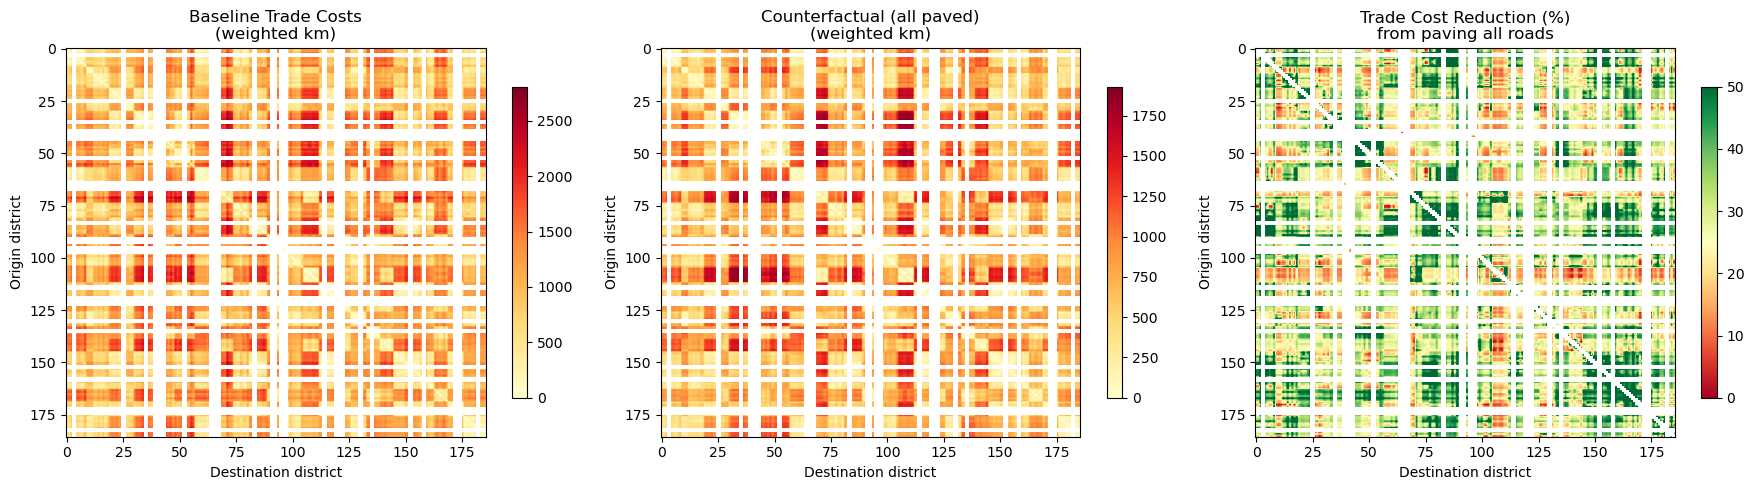


Mean trade cost reduction: 31.2%
This is the 'unpaved road tax' — what feeds into the GE model.


In [6]:
# Load the real data
tc_base = np.load('../data/processed/tanzania_trade_costs_baseline.npy')
tc_cf = np.load('../data/processed/tanzania_trade_costs_counterfactual.npy')
names = np.load('../data/processed/tanzania_admin2_names.npy', allow_pickle=True)

n_real = tc_base.shape[0]
print(f"Trade cost matrix: {n_real} × {n_real} = {n_real**2:,} entries")
print(f"Connected pairs: {np.isfinite(tc_base).sum() - n_real:,} / {n_real*(n_real-1):,}")

# Visualize as heatmaps
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Baseline
tc_plot = tc_base.copy()
tc_plot[~np.isfinite(tc_plot)] = np.nan
im1 = ax1.imshow(tc_plot, cmap='YlOrRd', aspect='auto')
ax1.set_title('Baseline Trade Costs\n(weighted km)', fontsize=12)
plt.colorbar(im1, ax=ax1, shrink=0.8)

# Counterfactual
tc_cf_plot = tc_cf.copy()
tc_cf_plot[~np.isfinite(tc_cf_plot)] = np.nan
im2 = ax2.imshow(tc_cf_plot, cmap='YlOrRd', aspect='auto')
ax2.set_title('Counterfactual (all paved)\n(weighted km)', fontsize=12)
plt.colorbar(im2, ax=ax2, shrink=0.8)

# Reduction
both = np.isfinite(tc_base) & np.isfinite(tc_cf) & (tc_base > 0)
reduction = np.full_like(tc_base, np.nan)
reduction[both] = 100 * (1 - tc_cf[both] / tc_base[both])
im3 = ax3.imshow(reduction, cmap='RdYlGn', aspect='auto', vmin=0, vmax=50)
ax3.set_title('Trade Cost Reduction (%)\nfrom paving all roads', fontsize=12)
plt.colorbar(im3, ax=ax3, shrink=0.8)

for ax in [ax1, ax2, ax3]:
    ax.set_xlabel('Destination district')
    ax.set_ylabel('Origin district')

plt.tight_layout()
plt.show()

# Summary stats
finite = tc_base[both]
reductions = 100 * (1 - tc_cf[both] / tc_base[both])
print(f"\nMean trade cost reduction: {reductions.mean():.1f}%")
print(f"This is the 'unpaved road tax' — what feeds into the GE model.")

## 7. From Graph to Economics

Here's how graphs connect to the GE model:

```
OSM Road Data          →  Graph              →  Trade Cost Matrix    →  GE Model
(1.1M segments)           (2M nodes,             (186 × 186)            (welfare,
 with surface tags)        2.6M edges,                                   wages,
                           weighted by                                   population)
                           surface type)
```

1. **Roads → Graph**: Each road segment becomes an edge. Intersections become nodes. Surface type determines edge weight.

2. **Graph → Trade Costs**: Dijkstra's algorithm computes the cheapest path between every pair of districts.

3. **Trade Costs → Economics**: The trade cost matrix tells the GE model how expensive it is to move goods between locations. Lower trade costs → more trade → more specialization → higher welfare.

4. **Counterfactual**: Set all edge weights to paved (multiply = 1.0), recompute shortest paths, re-solve the model. The welfare difference is the headline number.

**The graph is the bridge between geography and economics.** Everything physical about the road network — its topology, surface quality, connectivity — gets compressed into a single matrix of bilateral trade costs.

## 8. Key Takeaways

| Concept | What it is | Why it matters |
|---------|-----------|----------------|
| **Graph** | Nodes + edges | Abstracts road network into computable form |
| **Edge weight** | Cost of traversing a road segment | Captures distance AND surface quality |
| **Adjacency matrix** | n×n grid of edge weights | How we store the graph in memory |
| **Sparse matrix** | Only stores nonzero entries | Makes 2M×2M matrix feasible |
| **Dijkstra's algorithm** | Finds cheapest paths from one source to all destinations | Gives us bilateral trade costs |
| **Connected component** | Group of mutually reachable nodes | Disconnected = infinite trade cost |
| **Trade cost matrix** | n×n shortest-path distances between districts | The input to the GE model |
| **Counterfactual** | Same graph, different weights | What if all roads were paved? |